In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'IMG20250119150227.jpg',
 'Classroom',
 'Iktear-Hoque_232006912_AA200.3.pptx',
 'CODES',
 '232008212 Cse124 final assignment .pdf',
 '232008212 Cse124 final assignment .gdoc',
 'IMG20241006123907.jpg',
 '232006912_CSE225.pdf',
 'cse 226 assignment 5.pdf',
 'Share 232008212 cse225 database presentation.pptx',
 'Document 10.pdf',
 'Spring 25_CSE_Course Offer_regular (More Courses).docx',
 'IMG20250413101854.jpg',
 'Video ',
 'IMG_0618 (1).jpeg',
 'IMG_0618.jpeg',
 'IMG_0929.jpeg',
 'Graphics_final.pdf',
 'Archive',
 'bank-data']

In [4]:
import os

path = '/content/drive/MyDrive/bank-data'

print(os.listdir(path))

['bank-data', '__MACOSX']


In [5]:
import os

path = '/content/drive/MyDrive/bank-data/bank-data'

print(os.listdir(path))

['bank-full.csv', '.DS_Store']


In [6]:
import pandas as pd

file_path = '/content/drive/MyDrive/bank-data/bank-data/bank-full.csv'

df = pd.read_csv(file_path, sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (45211, 17)


In [8]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (45211, 17)


In [14]:
print(df['y'].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [15]:
print(df['y'].value_counts(normalize=True) * 100)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [17]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [18]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


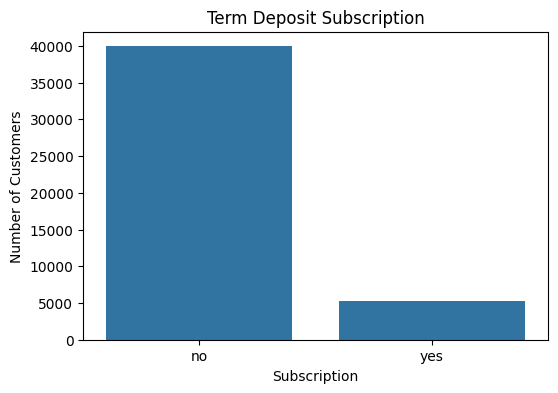

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='y')

plt.title('Term Deposit Subscription')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')

plt.show()

In [20]:
target_percentage = df['y'].value_counts(normalize=True) * 100

print(target_percentage)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [21]:
X_temp = df.drop('y', axis=1)

numeric_features = X_temp.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_temp.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [22]:
X = df.drop('y', axis=1)

y = df['y'].map({
    'no': 0,
    'yes': 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 16)
y shape: (45211,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 36168
Testing samples: 9043


In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

print("Logistic Regression model created!")

Logistic Regression model created!


In [26]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [27]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.901249585314608
Accuracy (%): 90.12495853146079


In [30]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6444833625218914


In [31]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.34782608695652173


In [32]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.4518109269490485


In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No', 'Yes']
    )
)

              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7782  203]
 [ 690  368]]


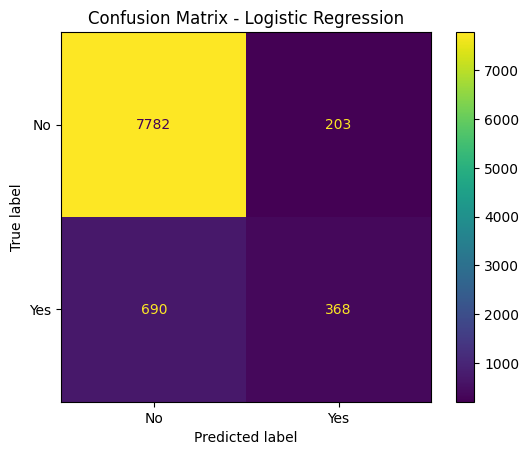

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

disp.plot()

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [36]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [37]:
correct = (y_test == y_pred).sum()
wrong = (y_test != y_pred).sum()

print("Total test samples:", len(y_test))
print("Correct predictions:", correct)
print("Wrong predictions:", wrong)

Total test samples: 9043
Correct predictions: 8150
Wrong predictions: 893


In [38]:
performance = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

performance

,Metric,Score
0,Accuracy,0.901250
1,Precision,0.644483
2,Recall,0.347826
3,F1 Score,0.451811


In [39]:
sample_customer = X_test.iloc[[0]]

prediction = model.predict(sample_customer)[0]

if prediction == 1:
    print("Prediction: Customer will subscribe to the term deposit.")
else:
    print("Prediction: Customer will NOT subscribe to the term deposit.")

Prediction: Customer will NOT subscribe to the term deposit.


In [40]:
probability = model.predict_proba(sample_customer)[0]

print("Probability of No:", probability[0])
print("Probability of Yes:", probability[1])

Probability of No: 0.9926316931044309
Probability of Yes: 0.007368306895569148


In [41]:
classifier = model.named_steps['classifier']

feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = classifier.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
49,cat__poutcome_success,1.549282,1.549282
42,cat__month_mar,1.457573,1.457573
39,cat__month_jan,-1.321511,1.321511
34,cat__contact_unknown,-1.201578,1.201578
3,num__duration,1.091874,1.091874
44,cat__month_nov,-0.927599,0.927599
40,cat__month_jul,-0.883044,0.883044
46,cat__month_sep,0.816278,0.816278
47,cat__poutcome_failure,-0.792804,0.792804
50,cat__poutcome_unknown,-0.778145,0.778145


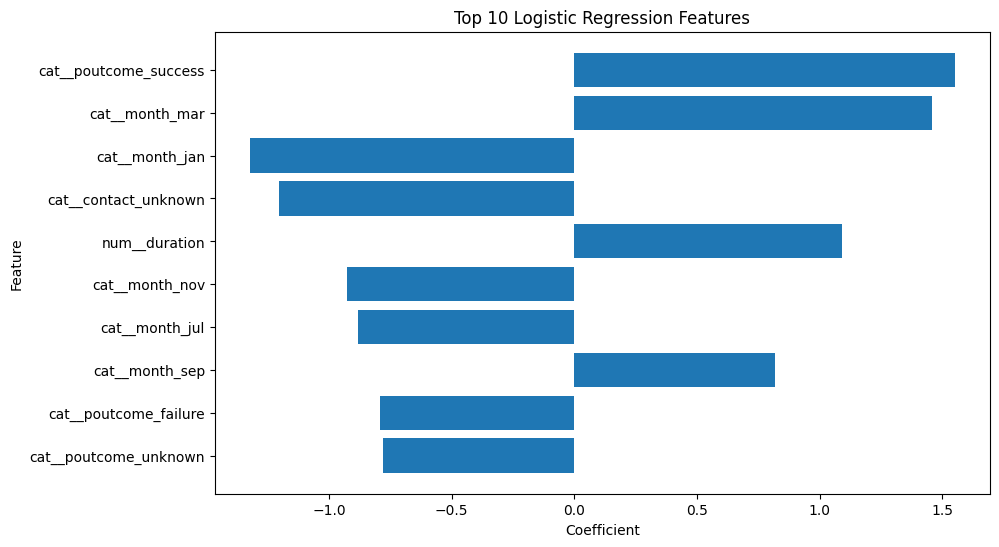

In [42]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Logistic Regression Features')

plt.gca().invert_yaxis()

plt.show()

In [43]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.901249585314608
Precision: 0.6444833625218914
Recall   : 0.34782608695652173
F1 Score : 0.4518109269490485


## Findings

The Logistic Regression model was used to predict whether a bank customer would subscribe to a term deposit.

The dataset was divided into 80% training data and 20% testing data. Numerical features were standardized using StandardScaler, while categorical features were converted into numerical form using One-Hot Encoding.

The model achieved an accuracy of 90.12% on the test dataset. The precision was 64.45%, recall was 34.78%, and the F1-score was 45.18%.

Although the model achieved high accuracy, its recall for customers who subscribed to the term deposit was relatively low. This indicates that the model correctly identifies many non-subscribing customers but misses a significant number of customers who actually subscribe.

Overall, Logistic Regression provides a useful baseline model for predicting term deposit subscription, but further improvement may be needed to better identify customers who are likely to subscribe.


In [44]:
final_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1
    ],
    'Percentage': [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
})

final_results

,Metric,Score,Percentage
0,Accuracy,0.901250,90.124959
1,Precision,0.644483,64.448336
2,Recall,0.347826,34.782609
3,F1 Score,0.451811,45.181093
